<a href="https://colab.research.google.com/github/UNIVERSALIONZ/Pipeline-1/blob/main/Pipeline_1_Training_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


[20:21:06] SMILES Parse Error: unclosed ring for input: 'NC1NC(O)C2NCN([C@@H]3O[C@H](CO[PH]([O-])(O)O[PH]([O-])(O)O)[C@@H](O)[C@H]3O)C2N21'
[20:21:06] SMILES Parse Error: unclosed ring for input: 'NC1CCN([C@@H]2O[C@H](CO[PH]([O-])(O)O)[C@@H](O)[C@H]2O)C(O)N6'
[20:21:06] SMILES Parse Error: unclosed ring for input: 'NC1CCN([C@@H]2O[C@H](CO[PH]([O-])(O)O)[C@@H](O)[C@H]2O)C(O)N14'
[20:21:06] SMILES Parse Error: unclosed ring for input: 'NC1NC(O)C2NCN([C@@H]3O[C@H](CO[PH]([O-])(O)O[PH]([O-])(O)O)[C@@H](O)[C@H]3O)C2N18'
[20:21:06] SMILES Parse Error: unclosed ring for input: 'NC1NC(O)C2NCN([C@@H]3O[C@H](CO[PH]([O-])(O)O[PH]([O-])(O)O)[C@@H](O)[C@H]3O)C2N39'
[20:21:06] SMILES Parse Error: unclosed ring for input: 'NC1NC(O)C2NCN([C@@H]3O[C@H](CO[PH]([O-])(O)O[PH]([O-])(O)O)[C@@H](O)[C@H]3O)C2N49'
[20:21:06] SMILES Parse Error: unclosed ring for input: 'NC1NC(O)C2NCN([C@@H]3O[C@H](CO[PH]([O-])(O)O[PH]([O-])(O)O)[C@@H](O)[C@H]3O)C2N54'
[20:21:06] SMILES Parse Error: unclosed ring for input: 'NC

AttributeError: 'NoneType' object has no attribute 'keys'

In [ ]:
import pandas as pd
import numpy as np
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SeqUtils import IsoelectricPoint
from Bio.PDB import PDBParser, DSSP
from sklearn.preprocessing import normalize
from collections import Counter
from subprocess import Popen, PIPE
import tempfile
import os
from rdkit import Chem
from rdkit.Chem import Descriptors

# Load the dataset
data = pd.read_csv("Dataset_P1_ML.csv")

In [ ]:
# Find rows with newline characters in the "Sequence" column
rows_with_newlines = data[data["Sequence"].astype(str).str.contains(r"\n", regex=True)]

# Display these rows
print(rows_with_newlines)

# Optionally, display row indices
print("Rows with \\n characters:", rows_with_newlines.index.tolist())

Empty DataFrame
Columns: [Protein_name, Chain_ID, Sequence, Ligand_name, SMILES, Binding_affinity]
Index: []
Rows with \n characters: []


In [ ]:
ligand_features_list = []
error_indices = []  # To store the indices of rows causing errors
error_smiles = []   # To store the SMILES strings causing errors

for idx, smiles in data["SMILES"].items():
    try:
        ligand_features = calculate_ligand_features(smiles)
        ligand_features_list.append(ligand_features)
    except Exception as e:
        print(f"Error at row {idx}, SMILES: {smiles}, Error: {e}")
        error_indices.append(idx)
        error_smiles.append(smiles)
        ligand_features_list.append(None)  # Append None to maintain indexing

# Create a DataFrame for errors (optional)
error_df = pd.DataFrame({
    "Index": error_indices,
    "SMILES": error_smiles
})
print("Rows with errors:")
print(error_df)

[20:34:10] SMILES Parse Error: unclosed ring for input: 'NC1NC(O)C2NCN([C@@H]3O[C@H](CO[PH]([O-])(O)O[PH]([O-])(O)O)[C@@H](O)[C@H]3O)C2N21'
[20:34:10] SMILES Parse Error: unclosed ring for input: 'NC1CCN([C@@H]2O[C@H](CO[PH]([O-])(O)O)[C@@H](O)[C@H]2O)C(O)N6'
[20:34:10] SMILES Parse Error: unclosed ring for input: 'NC1CCN([C@@H]2O[C@H](CO[PH]([O-])(O)O)[C@@H](O)[C@H]2O)C(O)N14'
[20:34:10] SMILES Parse Error: unclosed ring for input: 'NC1NC(O)C2NCN([C@@H]3O[C@H](CO[PH]([O-])(O)O[PH]([O-])(O)O)[C@@H](O)[C@H]3O)C2N18'
[20:34:10] SMILES Parse Error: unclosed ring for input: 'NC1NC(O)C2NCN([C@@H]3O[C@H](CO[PH]([O-])(O)O[PH]([O-])(O)O)[C@@H](O)[C@H]3O)C2N39'
[20:34:10] SMILES Parse Error: unclosed ring for input: 'NC1NC(O)C2NCN([C@@H]3O[C@H](CO[PH]([O-])(O)O[PH]([O-])(O)O)[C@@H](O)[C@H]3O)C2N49'
[20:34:10] SMILES Parse Error: unclosed ring for input: 'NC1NC(O)C2NCN([C@@H]3O[C@H](CO[PH]([O-])(O)O[PH]([O-])(O)O)[C@@H](O)[C@H]3O)C2N54'
[20:34:10] SMILES Parse Error: unclosed ring for input: 'NC

Rows with errors:
Empty DataFrame
Columns: [Index, SMILES]
Index: []


[20:34:10] SMILES Parse Error: unclosed ring for input: 'NC1CCN([C@@H]2O[C@H](CO[PH]([O-])(O)O)[C@@H](O)[C@H]2O)C(O)N12'
[20:34:10] SMILES Parse Error: unclosed ring for input: 'NC1NC(O)C2NCN([C@@H]3O[C@H](CO[PH]([O-])(O)O[PH]([O-])(O)O)[C@@H](O)[C@H]3O)C2N26'
[20:34:10] SMILES Parse Error: unclosed ring for input: 'NC1NC(O)C2NCN([C@@H]3O[C@H](CO[PH]([O-])(O)O[PH]([O-])(O)O)[C@@H](O)[C@H]3O)C2N44'
[20:34:10] SMILES Parse Error: unclosed ring for input: 'NC1CCN([C@@H]2O[C@H](CO[PH]([O-])(O)O[PH]([O-])(O)O)[C@@H](O)[C@H]2O)C(O)N5'
[20:34:10] SMILES Parse Error: unclosed ring for input: 'NC1NC(O)C2NCN([C@@H]3O[C@H](CO[PH]([O-])(O)O[PH]([O-])(O)O)[C@@H](O)[C@H]3O)C2N24'
[20:34:10] SMILES Parse Error: unclosed ring for input: 'NC1NC(O)C2NCN([C@@H]3O[C@H](CO[PH]([O-])(O)O[PH]([O-])(O)O)[C@@H](O)[C@H]3O)C2N25'
[20:34:10] SMILES Parse Error: unclosed ring for input: 'NC1NC(O)C2NCN([C@@H]3O[C@H](CO[PH]([O-])(O)O[PH]([O-])(O)O)[C@@H](O)[C@H]3O)C2N43'
[20:34:10] SMILES Parse Error: unclosed ring 

In [ ]:
import pandas as pd
import numpy as np
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SeqUtils import IsoelectricPoint
from Bio.PDB import PDBParser, DSSP
from sklearn.preprocessing import normalize
from collections import Counter
from subprocess import Popen, PIPE
import tempfile
import os
from rdkit import Chem
from rdkit.Chem import Descriptors

# Load the dataset
data = pd.read_csv("Dataset_P1_ML.csv")

# Function to calculate basic protein sequence features
def calculate_protein_features(sequence):
    analysis = ProteinAnalysis(sequence)
    amino_acid_composition = analysis.get_amino_acids_percent()
    features = {
        "seq_length": len(sequence),
        "aromaticity": analysis.aromaticity(),
        "instability_index": analysis.instability_index(),
        "isoelectric_point": analysis.isoelectric_point(),
        "gravy": analysis.gravy(),
        "molecular_weight": analysis.molecular_weight(),
        **amino_acid_composition,  # Adds composition for each amino acid
    }
    return features

# Function to calculate PSSM (requires external tools like PSI-BLAST)
def calculate_pssm(sequence, db="nr"):
    # Create a temporary FASTA file
    with tempfile.NamedTemporaryFile(delete=False, mode='w', suffix=".fasta") as fasta_file:
        fasta_file.write(f">query\n{sequence}\n")
        fasta_path = fasta_file.name

    # Run PSI-BLAST (Example, customize as per your local setup)
    pssm_path = fasta_path + ".pssm"
    try:
        command = f"psiblast -query {fasta_path} -db {db} -num_iterations 3 -out_ascii_pssm {pssm_path}"
        process = Popen(command, shell=True, stdout=PIPE, stderr=PIPE)
        process.communicate()
        if os.path.exists(pssm_path):
            # Parse PSSM to generate features
            pssm_features = parse_pssm(pssm_path)
        else:
            pssm_features = {}
    except Exception as e:
        pssm_features = {}
    finally:
        os.remove(fasta_path)
        if os.path.exists(pssm_path):
            os.remove(pssm_path)
    return pssm_features

def parse_pssm(pssm_file):
    # Parse PSSM file to extract average scores for each residue type
    with open(pssm_file, "r") as f:
        lines = f.readlines()
    pssm_data = [line.split() for line in lines if line.strip() and line[0].isdigit()]
    residue_scores = {aa: [] for aa in "ACDEFGHIKLMNPQRSTVWY"}
    for row in pssm_data:
        residue = row[1]
        scores = list(map(int, row[2:22]))  # Take raw PSSM scores
        residue_scores[residue].extend(scores)
    # Compute average PSSM scores for each residue type
    avg_scores = {f"pssm_{aa}": np.mean(scores) if scores else 0 for aa, scores in residue_scores.items()}
    return avg_scores

# Function to compute ligand features
def calculate_ligand_features(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        Chem.SanitizeMol(mol)
        features = {
            "mol_weight": Descriptors.MolWt(mol),
            "num_h_donors": Descriptors.NumHDonors(mol),
            "num_h_acceptors": Descriptors.NumHAcceptors(mol),
            "tpsa": Descriptors.TPSA(mol),
            "logp": Descriptors.MolLogP(mol),
            "num_rotatable_bonds": Descriptors.NumRotatableBonds(mol),
        }
        return features
    except:
        return None

# Generate protein features
protein_features_list = []
for seq in data["Sequence"]:
    protein_features = calculate_protein_features(seq)
    pssm_features = calculate_pssm(seq)
    protein_features.update(pssm_features)
    protein_features_list.append(protein_features)
protein_features_df = pd.DataFrame(protein_features_list)

# Generate ligand features
ligand_features_list = []
for smiles in data["SMILES"]:
    ligand_features = calculate_ligand_features(smiles)
    ligand_features_list.append(ligand_features)
ligand_features_df = pd.DataFrame(ligand_features_list)

# Combine all features with the original data
all_features = pd.concat([data, protein_features_df, ligand_features_df], axis=1)

# Drop rows with missing features (if any SMILES or sequences failed)
all_features = all_features.dropna()

# Save the processed features
all_features.to_csv("processed_features_extended.csv", index=False)

In [ ]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
from sklearn.feature_selection import *
from sklearn.feature_selection import VarianceThreshold

In [ ]:
import pandas as pd
file = './Ligand_28_features.csv'

In [ ]:
df1 = pd.read_csv(file)

In [ ]:
df1

,FileName,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,GDP-Man.pdb,12.354487,12.354487,0.086584,-5.890631,0.107021,46.820513,615.423,580.143,615.156500,...,0,0,0,0,0,0,0,0,0,0
1,ADP-heptose-F.pdb,14.378741,14.378741,0.204328,-6.035104,0.099565,44.900000,631.441,595.153,631.167814,...,0,0,0,0,0,0,0,0,0,0
2,dUDP.pdb,11.392482,11.392482,0.058337,-5.494705,0.209737,37.583333,396.226,374.050,396.070980,...,0,0,0,0,0,0,0,0,0,0
3,dTDP-Rham.pdb,12.226695,12.226695,0.012000,-5.736659,0.125877,44.971429,556.395,522.123,556.144539,...,0,0,0,0,0,0,0,0,0,0
4,CMP.pdb,10.673522,10.673522,0.317064,-4.975130,0.244953,43.190476,330.254,309.086,330.107175,...,0,0,0,0,0,0,0,0,0,0
5,UDP-GlcNac.pdb,12.520193,12.520193,0.045512,-5.898922,0.075594,42.435897,617.435,580.139,617.160917,...,0,0,0,0,0,0,0,0,0,0
6,CTP.pdb,11.741368,11.741368,0.176605,-5.978059,0.142150,36.931034,492.228,467.028,492.056583,...,0,0,0,0,0,0,0,0,0,0
7,ADP.pdb,9.943468,9.943468,0.204409,-4.741659,0.233875,43.190476,332.246,311.078,332.098467,...,0,0,0,0,0,0,0,0,0,0
8,TDP.pdb,11.435471,11.435471,0.051114,-5.502394,0.205083,39.560000,410.253,386.061,410.086630,...,0,0,0,0,0,0,0,0,0,0
9,UDP-Gal.pdb,11.411508,11.411508,0.111149,-5.557602,0.189807,39.560000,412.225,390.049,412.065895,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
x = df1.drop('FileName', axis=1)

In [ ]:
def remove_low_variance(input_data, threshold=0.1):
      selection = VarianceThreshold(threshold)
      selection.fit(input_data)
      return  input_data[input_data.columns[selection.get_support(indices=True)]]


      x = remove_low_variance(x, threshold=0.1)


In [ ]:
x

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,12.354487,12.354487,0.086584,-5.890631,0.107021,46.820513,615.423,580.143,615.156500,232,...,0,0,0,0,0,0,0,0,0,0
1,14.378741,14.378741,0.204328,-6.035104,0.099565,44.900000,631.441,595.153,631.167814,238,...,0,0,0,0,0,0,0,0,0,0
2,11.392482,11.392482,0.058337,-5.494705,0.209737,37.583333,396.226,374.050,396.070980,146,...,0,0,0,0,0,0,0,0,0,0
3,12.226695,12.226695,0.012000,-5.736659,0.125877,44.971429,556.395,522.123,556.144539,210,...,0,0,0,0,0,0,0,0,0,0
4,10.673522,10.673522,0.317064,-4.975130,0.244953,43.190476,330.254,309.086,330.107175,126,...,0,0,0,0,0,0,0,0,0,0
5,12.520193,12.520193,0.045512,-5.898922,0.075594,42.435897,617.435,580.139,617.160917,234,...,0,0,0,0,0,0,0,0,0,0
6,11.741368,11.741368,0.176605,-5.978059,0.142150,36.931034,492.228,467.028,492.056583,178,...,0,0,0,0,0,0,0,0,0,0
7,9.943468,9.943468,0.204409,-4.741659,0.233875,43.190476,332.246,311.078,332.098467,126,...,0,0,0,0,0,0,0,0,0,0
8,11.435471,11.435471,0.051114,-5.502394,0.205083,39.560000,410.253,386.061,410.086630,152,...,0,0,0,0,0,0,0,0,0,0
9,11.411508,11.411508,0.111149,-5.557602,0.189807,39.560000,412.225,390.049,412.065895,152,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

# Load the data
input_file = "Ligand_28_features.csv"  # Replace with your file path
output_file = "Ligand_top30_ft.csv"

data = pd.read_csv(input_file)
file_names = data["FileName"]

# Drop the "FileName" column (assuming it's the first column)
descriptor_data = data.iloc[:, 1:]

# Use VarianceThreshold to filter low-variance descriptors
selector = VarianceThreshold(threshold=0.01)  # Adjust threshold as needed
selector.fit(descriptor_data)

# Get the indices of descriptors that pass the threshold
selected_indices = selector.get_support(indices=True)

# Select descriptors based on variance threshold
filtered_data = descriptor_data.iloc[:, selected_indices]

# Further reduce to the top 30 descriptors (e.g., by variance or domain knowledge)
top_30_descriptors = filtered_data.iloc[:, :30]  # Adjust selection logic as needed

# Add back the "FileName" column
#top_30_data = pd.concat([file_names, top_30_descriptors], axis=1)

# Save to a new CSV file
#top_30_data.to_csv(output_file, index=False)

#print(f"Top 30 descriptors saved to {output_file}")

/home/sudipta/.local/lib/python3.10/site-packages/sklearn/feature_selection/_variance_threshold.py:114: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)


In [ ]:
filtered_data

,MaxAbsEStateIndex,MaxEStateIndex,MinEStateIndex,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,FpDensityMorgan1,FpDensityMorgan2,...,MolMR,fr_Al_OH,fr_Al_OH_noTert,fr_NH1,fr_NH2,fr_alkyl_halide,fr_bicyclic,fr_epoxide,fr_ether,fr_halogen
0,12.354487,12.354487,-5.890631,46.820513,615.423,580.143,615.156500,232,0.897436,1.564103,...,121.3027,7,7,3,1,0,1,0,2,0
1,14.378741,14.378741,-6.035104,44.900000,631.441,595.153,631.167814,238,1.025000,1.725000,...,125.0589,6,6,3,1,1,1,0,2,1
2,11.392482,11.392482,-5.494705,37.583333,396.226,374.050,396.070980,146,1.208333,1.875000,...,76.0805,3,3,1,0,0,0,0,1,0
3,12.226695,12.226695,-5.736659,44.971429,556.395,522.123,556.144539,210,0.971429,1.628571,...,111.8491,6,6,1,0,0,0,0,2,0
4,10.673522,10.673522,-4.975130,43.190476,330.254,309.086,330.107175,126,1.333333,2.000000,...,67.8201,3,3,1,1,0,0,0,1,0
5,12.520193,12.520193,-5.898922,42.435897,617.435,580.139,617.160917,234,1.000000,1.641026,...,122.7014,8,8,2,0,0,0,0,2,0
6,11.741368,11.741368,-5.978059,36.931034,492.228,467.028,492.056583,178,1.034483,1.655172,...,91.0577,3,3,1,1,0,0,0,1,0
7,9.943468,9.943468,-4.741659,43.190476,332.246,311.078,332.098467,126,1.142857,1.809524,...,68.0703,4,4,1,0,0,0,0,1,0
8,11.435471,11.435471,-5.502394,39.560000,410.253,386.061,410.086630,152,1.240000,1.880000,...,80.6275,3,3,1,0,0,0,0,1,0
9,11.411508,11.411508,-5.557602,39.560000,412.225,390.049,412.065895,152,1.120000,1.760000,...,77.4703,4,4,1,0,0,0,0,1,0


In [ ]:
output_file2 = "Ligand_top89_ft.csv"
top_89_data = pd.concat([file_names, filtered_data], axis=1)
top_89_data.to_csv(output_file2, index=False)

print(f"Top 89 descriptors saved to {output_file2}")

Top 89 descriptors saved to Ligand_top89_ft.csv


In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.ML.Descriptors.MoleculeDescriptors import MolecularDescriptorCalculator
from rdkit.Chem import Descriptors

# Load the dataset
input_file = "processed_features_extended.csv"  # Replace with your file path
output_file = "dataset_with_rdkit_features.csv"

# Load the dataset
data = pd.read_csv(input_file)

# Extract the SMILES column (5th column)
smiles_list = data.iloc[:, 4]  # Assuming SMILES is in the 5th column

# Define RDKit descriptors
descriptor_names = [desc[0] for desc in Descriptors.descList]
calculator = MolecularDescriptorCalculator(descriptor_names)

# Function to calculate RDKit descriptors
def calculate_rdkit_features(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return [None] * len(descriptor_names)
        return calculator.CalcDescriptors(mol)
    except Exception as e:
        print(f"Error calculating descriptors for SMILES: {smiles}, Error: {e}")
        return [None] * len(descriptor_names)

# Calculate features for each SMILES
rdkit_features = []
for smiles in smiles_list:
    rdkit_features.append(calculate_rdkit_features(smiles))

# Create a DataFrame with the RDKit features
rdkit_features_df = pd.DataFrame(rdkit_features, columns=descriptor_names)

# Append RDKit features to the original dataset
data_with_features = pd.concat([data, rdkit_features_df], axis=1)

# Save the updated dataset to a new CSV file
data_with_features.to_csv(output_file, index=False)

print(f"RDKit features added and saved to {output_file}")

[11:41:57] DEPRECATION WARNING: please use MorganGenerator
[11:41:57] DEPRECATION WARNING: please use MorganGenerator
[11:41:57] DEPRECATION WARNING: please use MorganGenerator
[11:41:57] DEPRECATION WARNING: please use MorganGenerator
[11:41:57] DEPRECATION WARNING: please use MorganGenerator
[11:41:57] DEPRECATION WARNING: please use MorganGenerator
[11:41:57] DEPRECATION WARNING: please use MorganGenerator
[11:41:57] DEPRECATION WARNING: please use MorganGenerator
[11:41:57] DEPRECATION WARNING: please use MorganGenerator
[11:41:57] DEPRECATION WARNING: please use MorganGenerator
[11:41:57] DEPRECATION WARNING: please use MorganGenerator
[11:41:57] DEPRECATION WARNING: please use MorganGenerator
[11:41:57] DEPRECATION WARNING: please use MorganGenerator
[11:41:57] DEPRECATION WARNING: please use MorganGenerator
[11:41:57] DEPRECATION WARNING: please use MorganGenerator
[11:41:57] DEPRECATION WARNING: please use MorganGenerator
[11:41:57] DEPRECATION WARNING: please use MorganGenerat

RDKit features added and saved to dataset_with_rdkit_features.csv


[11:42:02] DEPRECATION WARNING: please use MorganGenerator
[11:42:02] DEPRECATION WARNING: please use MorganGenerator
[11:42:02] DEPRECATION WARNING: please use MorganGenerator
[11:42:02] DEPRECATION WARNING: please use MorganGenerator
[11:42:02] DEPRECATION WARNING: please use MorganGenerator
[11:42:02] DEPRECATION WARNING: please use MorganGenerator
[11:42:02] DEPRECATION WARNING: please use MorganGenerator
[11:42:02] DEPRECATION WARNING: please use MorganGenerator
[11:42:02] DEPRECATION WARNING: please use MorganGenerator
[11:42:02] DEPRECATION WARNING: please use MorganGenerator
[11:42:02] DEPRECATION WARNING: please use MorganGenerator
[11:42:02] DEPRECATION WARNING: please use MorganGenerator
[11:42:02] DEPRECATION WARNING: please use MorganGenerator
[11:42:02] DEPRECATION WARNING: please use MorganGenerator
[11:42:02] DEPRECATION WARNING: please use MorganGenerator
[11:42:02] DEPRECATION WARNING: please use MorganGenerator
[11:42:02] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

# Load the data
input_file = "dataset_with_rdkit_features_withoutnames.csv"  # Replace with your file path
output_file = "dataset_reduced_features_lig_87_all.csv"

data = pd.read_csv(input_file)
#file_names = data["File_name"]

# Drop the "FileName" column (assuming it's the first column)
descriptor_data = data.iloc[:, 1:]

# Use VarianceThreshold to filter low-variance descriptors
selector = VarianceThreshold(threshold=0.01)  # Adjust threshold as needed
selector.fit(descriptor_data)

# Get the indices of descriptors that pass the threshold
selected_indices = selector.get_support(indices=True)

# Select descriptors based on variance threshold
filtered_data = descriptor_data.iloc[:, selected_indices]

# Further reduce to the top 30 descriptors (e.g., by variance or domain knowledge)
#top_30_descriptors = filtered_data.iloc[:, :30]  # Adjust selection logic as needed

/home/sudipta/.local/lib/python3.10/site-packages/sklearn/feature_selection/_variance_threshold.py:114: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)


In [ ]:
# Add back the "FileName" column
top_30_data = pd.concat([file_names, top_30_descriptors], axis=1)

# Save to a new CSV file
top_30_data.to_csv(output_file, index=False)

print(f"Top 30 descriptors saved to {output_file}")

Top 30 descriptors saved to Ligand_top30_ft.csv


In [ ]:
filtered_data

,MaxEStateIndex,MinEStateIndex,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,...,MolLogP,MolMR,fr_Al_OH,fr_Al_OH_noTert,fr_NH1,fr_NH2,fr_alkyl_halide,fr_bicyclic,fr_ether,fr_halogen
0,11.411508,-5.557602,39.560000,412.225,390.049,412.065895,152,1.120000,1.760000,2.320000,...,-6.1268,77.4703,4,4,1,0,0,0,1,0
1,11.411508,-5.557602,39.560000,412.225,390.049,412.065895,152,1.120000,1.760000,2.320000,...,-6.1268,77.4703,4,4,1,0,0,0,1,0
2,12.218905,-5.886254,44.055556,574.366,542.110,574.118718,216,0.861111,1.500000,2.111111,...,-8.3026,110.1037,8,8,1,0,0,0,2,0
3,11.411508,-5.557602,39.560000,412.225,390.049,412.065895,152,1.120000,1.760000,2.320000,...,-6.1268,77.4703,4,4,1,0,0,0,1,0
4,11.411508,-5.557602,39.560000,412.225,390.049,412.065895,152,1.120000,1.760000,2.320000,...,-6.1268,77.4703,4,4,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,12.232601,-5.989901,43.351351,590.365,558.109,590.113633,222,0.891892,1.540541,2.135135,...,-8.9842,111.2435,9,8,1,0,0,0,2,0
646,11.411508,-5.557602,39.560000,412.225,390.049,412.065895,152,1.120000,1.760000,2.320000,...,-6.1268,77.4703,4,4,1,0,0,0,1,0
647,11.411508,-5.557602,39.560000,412.225,390.049,412.065895,152,1.120000,1.760000,2.320000,...,-6.1268,77.4703,4,4,1,0,0,0,1,0
648,12.520193,-5.898922,42.435897,617.435,580.139,617.160917,234,1.000000,1.641026,2.230769,...,-8.3670,122.7014,8,8,2,0,0,0,2,0


In [ ]:
filtered_data.to_csv(output_file, index=False)


In [ ]:
import pandas as pd
import numpy as np

# Load the CSV file
def load_data(file_path):
    """
    Load the CSV file into a pandas DataFrame.
    """
    return pd.read_csv(file_path)

# Calculate the correlation matrix and remove highly correlated features
def reduce_correlated_features(df, correlation_threshold=0.9):
    """
    Reduce features by removing highly correlated columns.

    Args:
        df (pd.DataFrame): Input DataFrame with protein names, features, and binding affinity.
        correlation_threshold (float): Threshold above which features are considered correlated.

    Returns:
        pd.DataFrame: Reduced DataFrame with uncorrelated features.
    """
    # Separate protein name and binding affinity columns
    protein_name = df.iloc[:, 0]  # Assuming the first column is protein name
    binding_affinity = df.iloc[:, -1]  # Assuming the last column is binding affinity
    features = df.iloc[:, 1:-1]  # Remaining columns are features

    # Calculate the correlation matrix
    correlation_matrix = features.corr().abs()

    # Identify highly correlated features
    upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > correlation_threshold)]

    # Drop the highly correlated features
    reduced_features = features.drop(columns=to_drop)

    # Combine protein name, reduced features, and binding affinity back into a DataFrame
    reduced_df = pd.concat([protein_name, reduced_features, binding_affinity], axis=1)
    return reduced_df

# Save the reduced DataFrame to a CSV file
def save_data(df, output_file):
    """
    Save the reduced DataFrame to a CSV file.
    """
    df.to_csv(output_file, index=False)

# Main function to execute the process
def main(input_file, output_file, correlation_threshold=0.9):
    """
    Main function to reduce correlated features and save the output.

    Args:
        input_file (str): Path to the input CSV file.
        output_file (str): Path to the output CSV file.
        correlation_threshold (float): Threshold above which features are considered correlated.
    """
    # Load the data
    df = load_data(input_file)

    # Reduce correlated features
    reduced_df = reduce_correlated_features(df, correlation_threshold)

    # Save the reduced data
    save_data(reduced_df, output_file)

# Example usage
if __name__ == "__main__":
    input_file = "Dataset_NR.csv"  # Replace with your input file path
    output_file = "reduced_protein_data.csv"  # Replace with your desired output file path
    correlation_threshold = 0.9  # Adjust the threshold as needed

    main(input_file, output_file, correlation_threshold)

In [ ]:
! pip install padelpy


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 72.4 MB/s eta 0:00:000m eta 0:00:01


In [ ]:
! wget

wget: missing URL
Usage: wget [OPTION]... [URL]...

Try `wget --help' for more options.


In [ ]:
import pandas as pd
file = './reduced_protein_data.csv'
df1 = pd.read_csv(file)
df1.head(2)

,Protein_name,aromaticity,instability_index,isoelectric_point,gravy,molecular_weight,mol_weight,MaxEStateIndex,MinEStateIndex,SPS,...,HallKierAlpha,Ipc,SMR_VSA10,SMR_VSA3,SMR_VSA6,SlogP_VSA5,EState_VSA8,EState_VSA9,VSA_EState8,Binding_affinity
0,pdb8v9q.ent,0.090000,45.387820,8.174220,-0.417200,57382.1683,412.225,11.411508,-5.557602,39.56,...,0.3,181258.6831,16.340437,10.216698,13.151638,6.420822,14.151167,14.523686,-0.702921,-7.06
1,pdb8v9q.ent,0.091314,44.963719,8.797501,-0.442762,52145.3884,412.225,11.411508,-5.557602,39.56,...,0.3,181258.6831,16.340437,10.216698,13.151638,6.420822,14.151167,14.523686,-0.702921,-6.61


In [ ]:
x = df1.drop('Protein_name', axis=1)

In [ ]:
y = df1['Binding_affinity']

In [ ]:
x

,aromaticity,instability_index,isoelectric_point,gravy,molecular_weight,mol_weight,MaxEStateIndex,MinEStateIndex,SPS,FpDensityMorgan1,HallKierAlpha,Ipc,SMR_VSA10,SMR_VSA3,SMR_VSA6,SlogP_VSA5,EState_VSA8,EState_VSA9,VSA_EState8,Binding_affinity
0,0.090000,45.387820,8.174220,-0.417200,57382.1683,412.225,11.411508,-5.557602,39.560000,1.120000,0.30,1.812587e+05,16.340437,10.216698,13.151638,6.420822,14.151167,14.523686,-0.702921,-7.06
1,0.091314,44.963719,8.797501,-0.442762,52145.3884,412.225,11.411508,-5.557602,39.560000,1.120000,0.30,1.812587e+05,16.340437,10.216698,13.151638,6.420822,14.151167,14.523686,-0.702921,-6.61
2,0.087678,30.559716,6.537359,-0.098578,47183.2095,574.366,12.218905,-5.886254,44.055556,0.861111,0.10,4.178593e+07,16.340437,10.216698,19.758520,6.420822,18.674914,14.580253,-1.772023,-8.21
3,0.101777,48.307771,5.800783,-0.188691,70557.8419,412.225,11.411508,-5.557602,39.560000,1.120000,0.30,1.812587e+05,16.340437,10.216698,13.151638,6.420822,14.151167,14.523686,-0.702921,-7.47
4,0.102107,48.675543,5.800783,-0.182496,70342.6354,412.225,11.411508,-5.557602,39.560000,1.120000,0.30,1.812587e+05,16.340437,10.216698,13.151638,6.420822,14.151167,14.523686,-0.702921,-7.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,0.073469,39.139592,6.172737,-0.252245,27106.6604,590.365,12.232601,-5.989901,43.351351,0.891892,0.06,5.869714e+07,16.340437,10.216698,13.151638,6.420822,18.674914,9.473726,-0.944939,-8.38
646,0.121771,35.486347,8.677654,-0.369742,31362.6777,412.225,11.411508,-5.557602,39.560000,1.120000,0.30,1.812587e+05,16.340437,10.216698,13.151638,6.420822,14.151167,14.523686,-0.702921,-6.53
647,0.121771,35.486347,8.677654,-0.369742,31362.6777,412.225,11.411508,-5.557602,39.560000,1.120000,0.30,1.812587e+05,16.340437,10.216698,13.151638,6.420822,14.151167,14.523686,-0.702921,-6.74
648,0.134503,40.986550,8.488697,-0.402924,39671.7405,617.435,12.520193,-5.898922,42.435897,1.000000,0.06,1.546826e+08,16.340437,15.533487,19.758520,13.344559,19.467956,13.997473,-0.542920,-8.52


In [ ]:
y

0     -7.06
1     -6.61
2     -8.21
3     -7.47
4     -7.18
       ... 
645   -8.38
646   -6.53
647   -6.74
648   -8.52
649   -6.17
Name: Binding_affinity, Length: 650, dtype: float64

In [ ]:
!pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train.shape, x_test.shape

((520, 20), (130, 20))

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [ ]:
model = GaussianNB()
model.fit(x_train, y_train)

ValueError: Unknown label type: (array([-9.62, -9.55, -9.42, -9.34, -9.25, -9.23, -9.2 , -9.15, -9.13,
       -9.1 , -9.09, -9.03, -9.  , -8.97, -8.92, -8.9 , -8.86, -8.84,
       -8.83, -8.82, -8.78, -8.77, -8.75, -8.74, -8.73, -8.71, -8.7 ,
       -8.69, -8.68, -8.67, -8.65, -8.64, -8.61, -8.59, -8.56, -8.55,
       -8.54, -8.53, -8.52, -8.49, -8.47, -8.45, -8.43, -8.42, -8.41,
       -8.4 , -8.39, -8.38, -8.36, -8.35, -8.34, -8.33, -8.32, -8.29,
       -8.26, -8.25, -8.23, -8.22, -8.19, -8.17, -8.16, -8.15, -8.13,
       -8.12, -8.11, -8.1 , -8.09, -8.07, -8.06, -8.01, -8.  , -7.99,
       -7.98, -7.96, -7.94, -7.92, -7.9 , -7.89, -7.88, -7.87, -7.85,
       -7.83, -7.82, -7.8 , -7.77, -7.73, -7.72, -7.71, -7.7 , -7.68,
       -7.66, -7.64, -7.63, -7.62, -7.61, -7.59, -7.58, -7.57, -7.56,
       -7.55, -7.54, -7.53, -7.52, -7.51, -7.49, -7.48, -7.47, -7.46,
       -7.45, -7.43, -7.42, -7.4 , -7.39, -7.38, -7.37, -7.36, -7.35,
       -7.34, -7.33, -7.32, -7.31, -7.3 , -7.29, -7.28, -

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Assuming x and y are already defined
# Discretize y into categories
num_bins = 3  # Define the number of bins
y_binned = pd.qcut(y, q=num_bins, labels=False)  # Equal-sized bins

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y_binned, test_size=0.2, random_state=42)

# Initialize and train the model
model = GaussianNB()
model.fit(x_train, y_train)

# Predict and evaluate
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")

Accuracy: 0.46153846153846156


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# Assuming x and y are already defined
# Discretize y into categories
num_bins = 3  # Define the number of bins
y_binned = pd.qcut(y, q=num_bins, labels=False)  # Equal-sized bins

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y_binned, test_size=0.2, random_state=42)

# Initialize and train the model
model = GaussianNB()
model.fit(x_train, y_train)

# Predict and evaluate
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Extract TP, FN, FP, TN
if cm.shape == (2, 2):  # Binary classification case
    TN, FP, FN, TP = cm.ravel()
    sensitivity = TP / (TP + FN)  # Recall
    specificity = TN / (TN + FP)
else:
    sensitivity = specificity = "Not applicable for multi-class"

print(f"Accuracy: {accuracy}")
print(f"Sensitivity (Recall): {sensitivity}")
print(f"Specificity: {specificity}")

Accuracy: 0.46153846153846156
Sensitivity (Recall): Not applicable for multi-class
Specificity: Not applicable for multi-class


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
file = './reduced_protein_data.csv'
df1 = pd.read_csv(file)

# Prepare features and target
x = df1.drop('Protein_name', axis=1)
y = df1['Binding_affinity']

# Discretize y into categories
num_bins = 3  # Define the number of bins
y_binned = pd.qcut(y, q=num_bins, labels=False)  # Equal-sized bins

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y_binned, test_size=0.2, random_state=42)

# Initialize and train the model
model = GaussianNB()
model.fit(x_train, y_train)

# Predict and evaluate
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
num_classes = cm.shape[0]

# Compute Sensitivity and Specificity per class
sensitivity_per_class = {}
specificity_per_class = {}

for i in range(num_classes):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    sensitivity_per_class[i] = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity_per_class[i] = TN / (TN + FP) if (TN + FP) != 0 else 0

print(f"Accuracy: {accuracy}")
print("Sensitivity per class:", sensitivity_per_class)
print("Specificity per class:", specificity_per_class)

Accuracy: 0.46153846153846156
Sensitivity per class: {0: 0.32558139534883723, 1: 0.046511627906976744, 2: 1.0}
Specificity per class: {0: 0.9655172413793104, 1: 0.896551724137931, 2: 0.32558139534883723}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import matthews_corrcoef


model = RandomForestClassifier (n_estimators=500, random_state=42)
model.fit(x_train, y_train)


RandomForestClassifier(n_estimators=500, random_state=42)

In [ ]:
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)


In [ ]:
mcc_train = matthews_corrcoef(y_train, y_train_pred)
mcc_train

1.0

In [ ]:
mcc_test = matthews_corrcoef(y_test, y_test_pred)
mcc_test

0.9885496183206107

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
rf = RandomForestClassifier(n_estimators=500, random_state=42)
cv_scores = cross_val_score(rf, x_train, y_train, cv=5)
cv_scores

array([0.99038462, 0.98076923, 0.99038462, 0.99038462, 1.        ])

In [ ]:
mcc_cv = cv_scores.mean()
mcc_cv

0.9903846153846153

In [ ]:
model_name = pd.Series(['Random forest'], name='Name')
mcc_train_series = pd.Series(mcc_train, name='MCC_train')
mcc_cv_series = pd.Series(mcc_cv, name='MCC_cv')
mcc_test_series = pd.Series(mcc_test, name='MCC_test')

In [ ]:
performance_metrics = pd.concat([model_name, mcc_train_series, mcc_cv_series, mcc_test_series], axis=1)

In [ ]:
performance_metrics

,Name,MCC_train,MCC_cv,MCC_test
0,Random forest,1.0,0.990385,0.98855


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
def load_data(file_path, threshold):
    """
    Load the dataset from a CSV file and binarize the target.

    Args:
        file_path (str): Path to the CSV file.
        threshold (float): Threshold to binarize the target variable.

    Returns:
        tuple: Feature matrix (x) and binary target vector (y).
    """
    df = pd.read_csv(file_path)
    x = df.iloc[:, 1:-1]  # All columns except the first (name) and last (target)
    y = (df.iloc[:, -1] > threshold).astype(int)  # Binarize target
    return x, y

# Preprocess data
def preprocess_data(x):
    """
    Standardize the feature matrix.

    Args:
        x (ndarray): Feature matrix.

    Returns:
        ndarray: Scaled feature matrix.
    """
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x)
    return x_scaled

# Train and evaluate SVM model
def train_svm_model(x, y):
    """
    Train an SVM model and evaluate its performance.

    Args:
        x (ndarray): Feature matrix.
        y (ndarray): Target vector.

    Returns:
        None
    """
    # Preprocess the features
    x_scaled = preprocess_data(x)

    # Split data into training and testing sets
    x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

    # Initialize and train the SVM model
    model = SVC(kernel='rbf', random_state=42)
    model.fit(x_train, y_train)

    # Make predictions
    y_pred = model.predict(x_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

# Main function
def main():
    """
    Main function to execute the SVM model workflow.
    """
    # File path to the dataset
    file_path = "reduced_protein_data.csv"
    threshold = -7.0  # Example threshold for binarizing y

    # Load the data
    x, y = load_data(file_path, threshold)

    # Train and evaluate the SVM model
    train_svm_model(x, y)

if __name__ == "__main__":
    main()

Accuracy: 0.8153846153846154
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82        65
           1       0.84      0.78      0.81        65

    accuracy                           0.82       130
   macro avg       0.82      0.82      0.82       130
weighted avg       0.82      0.82      0.82       130



Defaulting to user installation because normal site-packages is not writeable


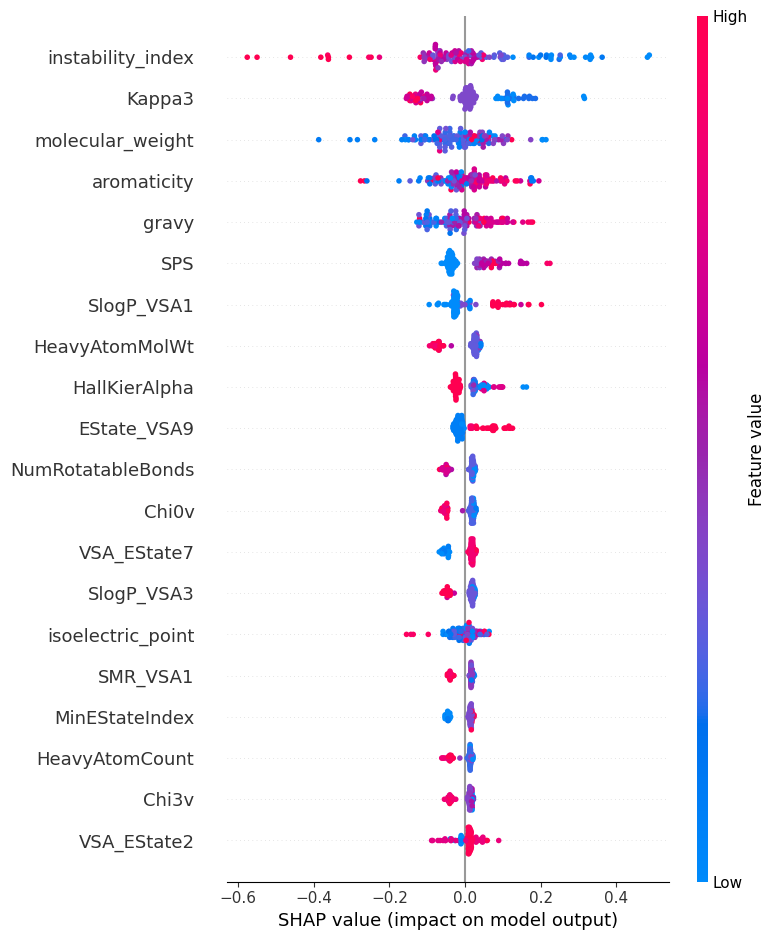

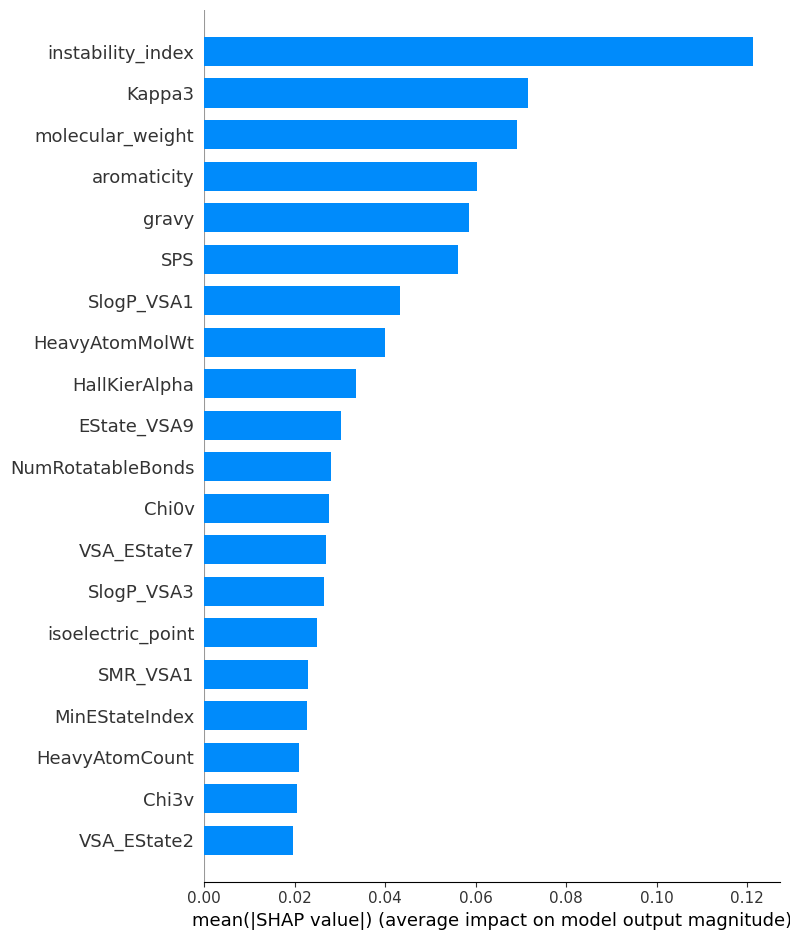

In [ ]:
!pip install shap
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Load the dataset
file_path = '/media/sudipta/638a7113-11e4-49cc-8a8f-e369d3ce1bd1/ML_PI/Pipeline_1/Ligands/ML_features/Dataset_NR.csv'  # Replace with the path to your CSV file
data = pd.read_csv(file_path)

# Define features and target
X = data.drop(columns=['Protein_name', 'Binding_affinity'])  # Exclude protein names and target
y = data['Binding_affinity']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Explain the model's predictions using SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

plt.savefig("shapely3.png")

# Feature importance plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

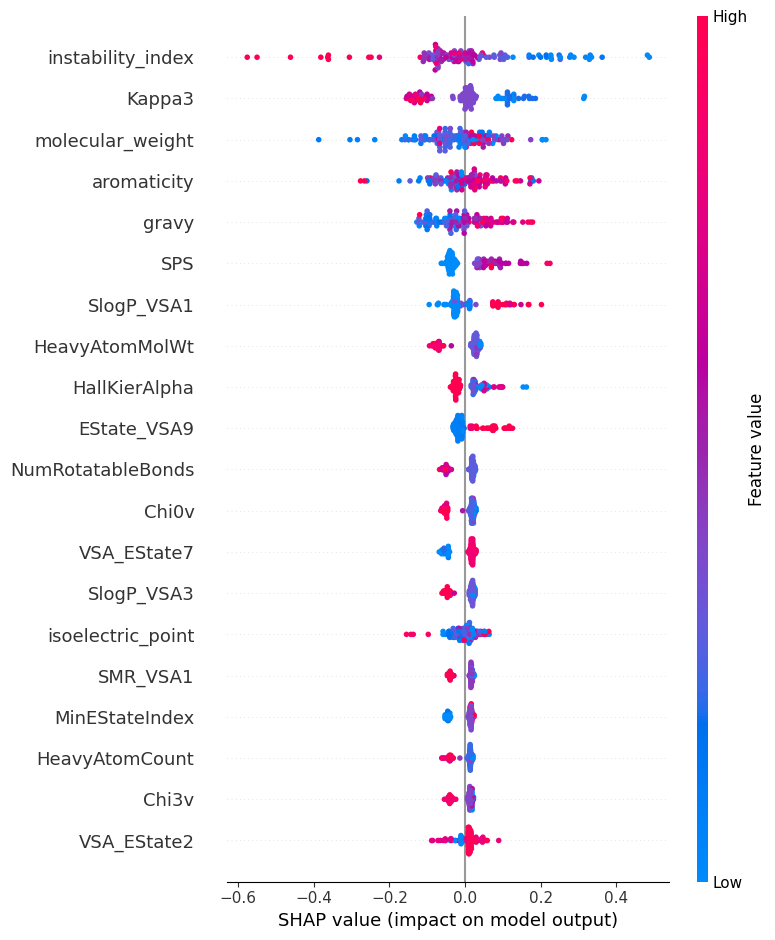

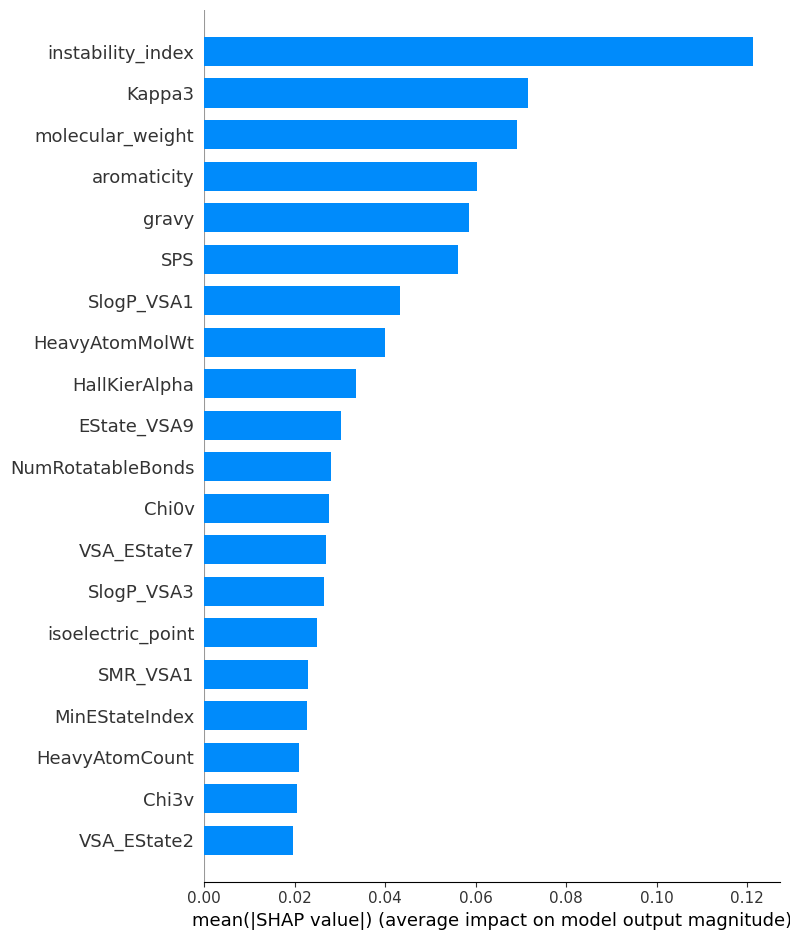

Top 20 SHAP features saved to 'shap_top_features.csv'.


In [ ]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Load the dataset
file_path = '/media/sudipta/638a7113-11e4-49cc-8a8f-e369d3ce1bd1/ML_PI/Pipeline_1/Ligands/ML_features/Dataset_NR.csv'  # Replace with the path to your CSV file
data = pd.read_csv(file_path)

# Define features and target
X = data.drop(columns=['Protein_name', 'Binding_affinity'])  # Exclude protein names and target
y = data['Binding_affinity']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Explain the model's predictions using SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

# Save the plot
plt.savefig("shapely3.png")

# Feature importance plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Save only the important features
# Calculate mean absolute SHAP values for each feature
mean_shap_values = pd.DataFrame(shap_values, columns=X_test.columns).abs().mean(axis=0)

# Sort features by importance (descending order)
sorted_features = mean_shap_values.sort_values(ascending=False)

# Extract top N features (e.g., top 20)
N = 20  # Change this number to get more or fewer features
top_features = sorted_features.head(N).index.tolist()

# Prepare the CSV file with protein_name, features, and binding_affinity
protein_names = data.loc[X_test.index, 'Protein_name']  # Get protein names for the test set
binding_affinities = y_test.values  # Get binding affinities for the test set

# Create a DataFrame for saving
output_df = pd.DataFrame({
    "protein_name": [protein_names.iloc[0]] * len(top_features),  # Using the first protein name
    "features": top_features,
    "Binding_affinity": [binding_affinities.mean()] * len(top_features)  # Average binding affinity
})

# Save to CSV
output_df.to_csv("shap_top_features.csv", index=False)

print(f"Top {N} SHAP features saved to 'shap_top_features.csv'.")

In [ ]:
import pandas as pd

# Load the existing CSV file
existing_df = pd.read_csv("shap_top_features.csv")

# Filter the rows where `features` are in the `important_features` list
filtered_df = existing_df[existing_df["features"].isin(important_features)]

# Save the filtered DataFrame to a new CSV file
filtered_df.to_csv("filtered_shap_features.csv", index=False)

print("Filtered CSV saved as 'filtered_shap_features.csv'.")

NameError: name 'important_features' is not defined

In [ ]:
import pandas as pd

# Define `important_features` (e.g., top N features from SHAP analysis)
important_features = [
    "instability_index",
"Kappa3",
"molecular_weight",
"aromaticity",
"gravy",
"SPS",
"SlogP_VSA1",
"HeavyAtomMolWt",
"HallKierAlpha",
"EState_VSA9",
"NumRotatableBonds",
"Chi0v",
"VSA_EState7",
"SlogP_VSA3",
"isoelectric_point",
"SMR_VSA1",
"MinEStateIndex",
"HeavyAtomCount",
"Chi3v",
"VSA_EState2"

]

# Load the existing CSV file
# Replace "shap_features.csv" with the actual path to your CSV file if it exists
existing_df = pd.read_csv("shap_top_features.csv")

# Filter the rows where `features` are in the `important_features` list
filtered_df = existing_df[existing_df["features"].isin(important_features)]

# Save the filtered DataFrame to a new CSV file
filtered_df.to_csv("filtered_shap_features.csv", index=False)

print("Filtered CSV saved as 'filtered_shap_features.csv'.")

Filtered CSV saved as 'filtered_shap_features.csv'.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
file = './reduced_protein_data.csv'
df1 = pd.read_csv(file)

# Prepare features and target
x = df1.drop('Protein_name', axis=1)
y = df1['Binding_affinity']
y_binary = (y >= y.median()).astype(int)  # Convert to binary

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y_binary, test_size=0.2, random_state=42)

# Define model
model = GaussianNB()

# No hyperparameters to tune for GaussianNB

# Train model
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f"GaussianNB - Accuracy: {accuracy:.4f}, Sensitivity: {sensitivity:.4f}, Specificity: {specificity:.4f}")

GaussianNB - Accuracy: 0.6692, Sensitivity: 1.0000, Specificity: 0.3175


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
file = './reduced_protein_data.csv'
df1 = pd.read_csv(file)

# Prepare features and target
x = df1.drop('Protein_name', axis=1)
y = df1['Binding_affinity']
y_binary = (y >= y.median()).astype(int)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y_binary, test_size=0.2, random_state=42)

# Define model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter tuning using RandomizedSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
random_search = RandomizedSearchCV(rf, param_grid, cv=5, n_iter=10, random_state=42, n_jobs=-1)
random_search.fit(x_train, y_train)

# Train best model
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(x_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f"RandomForest - Accuracy: {accuracy:.4f}, Sensitivity: {sensitivity:.4f}, Specificity: {specificity:.4f}")

RandomForest - Accuracy: 1.0000, Sensitivity: 1.0000, Specificity: 1.0000


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
file = './reduced_protein_data.csv'
df1 = pd.read_csv(file)

# Prepare features and target
x = df1.drop('Protein_name', axis=1)
y = df1['Binding_affinity']
y_binary = (y >= y.median()).astype(int)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y_binary, test_size=0.2, random_state=42)

# Define model
gbm = GradientBoostingClassifier(random_state=42)

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 10]
}
grid_search = GridSearchCV(gbm, param_grid, cv=5, n_jobs=-1)
grid_search.fit(x_train, y_train)

# Train best model
best_gbm = grid_search.best_estimator_
y_pred = best_gbm.predict(x_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f"GradientBoosting - Accuracy: {accuracy:.4f}, Sensitivity: {sensitivity:.4f}, Specificity: {specificity:.4f}")

GradientBoosting - Accuracy: 1.0000, Sensitivity: 1.0000, Specificity: 1.0000


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
file = './reduced_protein_data.csv'
df1 = pd.read_csv(file)

# Prepare features and target
x = df1.drop('Protein_name', axis=1)
y = df1['Binding_affinity']
y_binary = (y >= y.median()).astype(int)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y_binary, test_size=0.2, random_state=42)

# Define model
svm = SVC()

# Hyperparameter tuning using GridSearchCV
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid_search = GridSearchCV(svm, param_grid, cv=5, n_jobs=-1)
grid_search.fit(x_train, y_train)

# Train best model
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(x_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f"SVM - Accuracy: {accuracy:.4f}, Sensitivity: {sensitivity:.4f}, Specificity: {specificity:.4f}")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
file = './reduced_protein_data.csv'
df1 = pd.read_csv(file)

# Prepare features and target
x = df1.drop('Protein_name', axis=1)
y = df1['Binding_affinity']
y_binary = (y >= y.median()).astype(int)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y_binary, test_size=0.2, random_state=42)

# Define model
log_reg = LogisticRegression()

# Hyperparameter tuning using GridSearchCV
param_grid = {'C': [0.1, 1, 10], 'penalty': ['l2']}
grid_search = GridSearchCV(log_reg, param_grid, cv=5, n_jobs=-1)
grid_search.fit(x_train, y_train)

# Train best model
best_log_reg = grid_search.best_estimator_
y_pred = best_log_reg.predict(x_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f"LogisticRegression - Accuracy: {accuracy:.4f}, Sensitivity: {sensitivity:.4f}, Specificity: {specificity:.4f}")